In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# загрузка данных

anime_df = pd.read_csv('anime.csv')
rating_df = pd.read_csv('rating.csv')

# очистка: удаляем оценки -1
rating_df = rating_df[rating_df['rating'] != -1]

# заполняем пропуски
anime_df['genre'] = anime_df['genre'].fillna('Unknown')
anime_df['type'] = anime_df['type'].fillna('Unknown')

print(f"Аниме: {len(anime_df)}")
print(f"Оценок: {len(rating_df):,}")
print(f"Пользователей: {rating_df['user_id'].nunique():,}")

Аниме: 12294
Оценок: 6,337,241
Пользователей: 69,600


## подготовка контентных признаков

In [3]:
# жанры: заменяем запятые на пробелы и приводим к нижнему регистру
anime_df['genre_clean'] = anime_df['genre'].str.replace(',', ' ').str.lower()

# пип аниме (TV, Movie, OVA и т.д.)
anime_df['type_clean'] = anime_df['type'].str.lower()

# базовый признак: только жанры + тип
anime_df['combined_features'] = anime_df['genre_clean'] + ' ' + anime_df['type_clean']

print("\nПример признаков:")
print(anime_df[['name', 'genre', 'type', 'combined_features']].head(3))


Пример признаков:
                               name  \
0                    Kimi no Na wa.   
1  Fullmetal Alchemist: Brotherhood   
2                          Gintama°   

                                               genre   type  \
0               Drama, Romance, School, Supernatural  Movie   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV   

                                   combined_features  
0         drama  romance  school  supernatural movie  
1  action  adventure  drama  fantasy  magic  mili...  
2  action  comedy  historical  parody  samurai  s...  


## векторизация TF-IDF и косинусное сходство

In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=300)
tfidf_matrix = tfidf.fit_transform(anime_df['combined_features'])
print(f"\nTF-IDF матрица: {tfidf_matrix.shape}")

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Матрица сходства: {cosine_sim.shape}")


TF-IDF матрица: (12294, 52)
Матрица сходства: (12294, 12294)


## функция для поиска похожих аниме

In [5]:
def get_similar_anime(anime_name, top_n=10):
    """Поиск топ-N аниме, похожих по контенту"""
    # ищем аниме по названию (регистронезависимо)
    matches = anime_df[anime_df['name'].str.contains(anime_name, case=False, na=False)]
    if matches.empty:
        return f"Аниме '{anime_name}' не найдено."
    
    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    results = []
    for i, score in sim_scores:
        results.append({
            'Name': anime_df.iloc[i]['name'],
            'Genre': anime_df.iloc[i]['genre'],
            'Type': anime_df.iloc[i]['type'],
            'Similarity': round(score, 3)
        })
    return pd.DataFrame(results)

print("Аниме похожие на 'Death Note':")

display(get_similar_anime('Death Note', top_n=5))

Аниме похожие на 'Death Note':


,Name,Genre,Type,Similarity
0,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",TV,0.969
1,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",Special,0.944
2,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",TV,0.885
3,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,0.823
4,Higurashi no Naku Koro ni Rei,"Comedy, Mystery, Psychological, Supernatural, ...",OVA,0.821


## предсказанме оценок для content based

In [6]:
# создаем маппинг anime_id -> индекс в матрице сходства
anime_id_to_idx = dict(zip(anime_df['anime_id'], anime_df.index))

# разделяем оценки на train/test (80/20)
train_data, test_data = train_test_split(rating_df, test_size=0.2, random_state=42)
user_train_ratings = train_data.groupby('user_id')

def predict_rating_cb(user_id, anime_id, min_sim=0.1):
    """
    Предсказание оценки: взвешенное среднее оценок похожих аниме,
    которые пользователь уже оценил.
    """
    if anime_id not in anime_id_to_idx:
        return None
    
    target_idx = anime_id_to_idx[anime_id]
    
    if user_id not in user_train_ratings.groups:
        return None
    
    watched = user_train_ratings.get_group(user_id)
    
    weighted_sum = 0.0
    sim_sum = 0.0
    
    for _, row in watched.iterrows():
        watched_id = row['anime_id']
        if watched_id not in anime_id_to_idx:
            continue
        
        watched_idx = anime_id_to_idx[watched_id]
        sim = cosine_sim[target_idx, watched_idx]
        
        if sim > min_sim:
            weighted_sum += sim * row['rating']
            sim_sum += sim
    
    if sim_sum > 0:
        return weighted_sum / sim_sum
    return None

## расчет метрик для content based

In [7]:
# для ускорения берем выборку из тестовых данных
test_sample = test_data.sample(min(3000, len(test_data)), random_state=42)

actual = []
predicted = []

for _, row in test_sample.iterrows():
    pred = predict_rating_cb(row['user_id'], row['anime_id'])
    if pred is not None:
        actual.append(row['rating'])
        predicted.append(pred)

rmse_cb = sqrt(mean_squared_error(actual, predicted))
mae_cb = mean_absolute_error(actual, predicted)

print(f"\nМетрики для content based")
print(f"Выборка: {len(actual)} оценок")
print(f"RMSE: {rmse_cb:.4f}")
print(f"MAE:  {mae_cb:.4f}")


Метрики для content based
Выборка: 2999 оценок
RMSE: 1.3567
MAE:  1.0287


## сравнение KNN и SVD

In [8]:
from surprise import Dataset, Reader, KNNBasic, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy

print("Сравнение моделей на данных аниме")

# подготовка данных для Surprise
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(rating_df[['user_id', 'anime_id', 'rating']], reader)

trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

# KNN Item-Based
print("\n1. Обучаем KNN (Item-Based)")
knn = KNNBasic(k=20, sim_options={'name': 'cosine', 'user_based': False}, verbose=False)
knn.fit(trainset)
pred_knn = knn.test(testset)
rmse_knn = accuracy.rmse(pred_knn, verbose=False)
mae_knn = accuracy.mae(pred_knn, verbose=False)

# SVD
print("2. Обучаем SVD")
svd = SVD(n_factors=100, random_state=42)
svd.fit(trainset)
pred_svd = svd.test(testset)
rmse_svd = accuracy.rmse(pred_svd, verbose=False)
mae_svd = accuracy.mae(pred_svd, verbose=False)

# результаты
results = pd.DataFrame({
    'Модель': ['Content-Based (TF-IDF)', 'KNN (Item-Based)', 'SVD (FunkSVD)'],
    'Тип': ['Контентная', 'Коллаборативная', 'Коллаборативная'],
    'Что использует': ['Жанры + Тип', 'Оценки пользователей', 'Латентные факторы'],
    'RMSE': [rmse_cb, rmse_knn, rmse_svd],
    'MAE': [mae_cb, mae_knn, mae_svd]
})

print("\nИтоговое сравнение:")
display(results)

Сравнение моделей на данных аниме

1. Обучаем KNN (Item-Based)
2. Обучаем SVD

Итоговое сравнение:


,Модель,Тип,Что использует,RMSE,MAE
0,Content-Based (TF-IDF),Контентная,Жанры + Тип,1.356738,1.028657
1,KNN (Item-Based),Коллаборативная,Оценки пользователей,1.284560,0.961668
2,SVD (FunkSVD),Коллаборативная,Латентные факторы,1.131362,0.843450


## решила попробовать улучшить, добавила дополнительные признаки

In [12]:
# добавила категориальные признаки на основе числовых
# эпизоды
anime_df['episodes'] = pd.to_numeric(anime_df['episodes'], errors='coerce').fillna(12)
anime_df['ep_cat'] = anime_df['episodes'].apply(
    lambda x: 'short' if x <= 12 else ('medium' if x <= 26 else 'long')
)

# популярность (members)
anime_df['members'] = pd.to_numeric(anime_df['members'], errors='coerce').fillna(0)
anime_df['pop_cat'] = anime_df['members'].apply(
    lambda x: 'very_popular' if x > 200000 else ('popular' if x > 50000 else ('normal' if x > 5000 else 'niche'))
)

# средний рейтинг на сайте
anime_df['site_rating'] = pd.to_numeric(anime_df['rating'], errors='coerce').fillna(5.0)
anime_df['rating_cat'] = anime_df['site_rating'].apply(
    lambda x: 'excellent' if x > 8 else ('good' if x > 7 else ('average' if x > 5 else 'poor'))
)

# расширенный текстовый признак
anime_df['combined_v2'] = (
    anime_df['genre_clean'] + ' ' +
    anime_df['type_clean'] + ' ' +
    anime_df['ep_cat'] + ' ' +
    anime_df['pop_cat'] + ' ' +
    anime_df['rating_cat']
)

# векторизация с биграммами
tfidf_v2 = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1, 2))
tfidf_matrix_v2 = tfidf_v2.fit_transform(anime_df['combined_v2'])
cosine_sim_v2 = cosine_similarity(tfidf_matrix_v2, tfidf_matrix_v2)

# обновленная функция предсказания (с центрированием и top-k)
def predict_rating_cb_v2(user_id, anime_id, k=20):
    if anime_id not in anime_id_to_idx:
        return None
    if user_id not in user_train_ratings.groups:
        return None
    
    target_idx = anime_id_to_idx[anime_id]
    watched = user_train_ratings.get_group(user_id)
    
    # средняя оценка пользователя (для центрирования)
    user_mean = watched['rating'].mean()
    
    similarities = []
    centered_ratings = []
    
    for _, row in watched.iterrows():
        watched_id = row['anime_id']
        if watched_id not in anime_id_to_idx:
            continue
        
        watched_idx = anime_id_to_idx[watched_id]
        sim = cosine_sim_v2[target_idx, watched_idx]
        
        if sim > 0.05:
            similarities.append(sim)
            centered_ratings.append(row['rating'] - user_mean)
    
    if not similarities:
        return user_mean
    
    # берем топ-K самых похожих
    paired = sorted(zip(similarities, centered_ratings), key=lambda x: x[0], reverse=True)[:k]
    sims, rats = zip(*paired)
    
    if sum(sims) > 0:
        return user_mean + np.average(rats, weights=sims)
    return user_mean

# расчет метрик для улучшенной модели
actual_v2, pred_v2 = [], []
for _, row in test_sample.iterrows():
    pred = predict_rating_cb_v2(row['user_id'], row['anime_id'])
    if pred is not None:
        actual_v2.append(row['rating'])
        pred_v2.append(pred)

rmse_cb_v2 = sqrt(mean_squared_error(actual_v2, pred_v2))
mae_cb_v2 = mean_absolute_error(actual_v2, pred_v2)

print(f"\nУлучшенная модель:")
print(f"  RMSE: {rmse_cb_v2:.4f} (было {rmse_cb:.4f})")
print(f"  MAE:  {mae_cb_v2:.4f} (было {mae_cb:.4f})")
print(f"  Улучшение RMSE: {(1 - rmse_cb_v2/rmse_cb)*100:.1f}%")

# Финальное сравнение всех моделей
final_comparison = pd.DataFrame({
    'Модель': ['Content-Based (базовая)', 'Content-Based (улучшенная)', 'KNN (Item-Based)', 'SVD'],
    'RMSE': [rmse_cb, rmse_cb_v2, rmse_knn, rmse_svd],
    'MAE': [mae_cb, mae_cb_v2, mae_knn, mae_svd]
})

print("\nФинальное сравнение всех моделей:")

display(final_comparison.sort_values('RMSE'))


Улучшенная модель:
  RMSE: 1.2614 (было 1.3567)
  MAE:  0.9485 (было 1.0287)
  Улучшение RMSE: 7.0%

Финальное сравнение всех моделей:


,Модель,RMSE,MAE
3,SVD,1.131362,0.843450
1,Content-Based (улучшенная),1.261356,0.948462
2,KNN (Item-Based),1.284560,0.961668
0,Content-Based (базовая),1.356738,1.028657


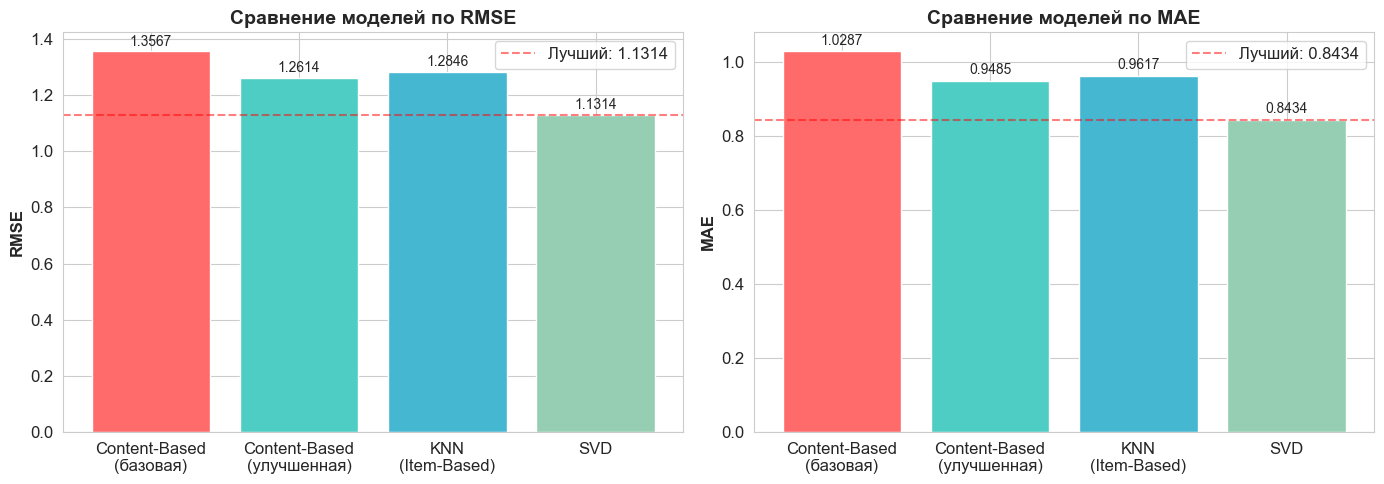

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Данные для визуализации
models = ['Content-Based\n(базовая)', 'Content-Based\n(улучшенная)', 'KNN\n(Item-Based)', 'SVD']
rmse_values = [rmse_cb, rmse_cb_v2, rmse_knn, rmse_svd]
mae_values = [mae_cb, mae_cb_v2, mae_knn, mae_svd]

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График RMSE
bars1 = ax1.bar(models, rmse_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('Сравнение моделей по RMSE', fontsize=14, fontweight='bold')
ax1.axhline(y=min(rmse_values), color='red', linestyle='--', alpha=0.5, label=f'Лучший: {min(rmse_values):.4f}')
ax1.legend()

# Подписи значений на столбцах
for bar, val in zip(bars1, rmse_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# График MAE
bars2 = ax2.bar(models, mae_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('Сравнение моделей по MAE', fontsize=14, fontweight='bold')
ax2.axhline(y=min(mae_values), color='red', linestyle='--', alpha=0.5, label=f'Лучший: {min(mae_values):.4f}')
ax2.legend()

for bar, val in zip(bars2, mae_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()